# 04 - Feature Engineering

Goal: Take the *clean* dataset from notebook 03 and engineer features that help a
linear model capture the real relationship between a car's specs and its 0–100 time.

We add features one at a time, re-evaluating after each, so we can see exactly which
feature earns its place. This mirrors the lab's approach: same data, smarter features,
better model.

Reference points (same model, same evaluation):
- Dirty baseline (notebook 02): see the red line on the progression chart below
- After cleaning (notebook 03): essentially unchanged from the dirty baseline

Cleaning alone barely moved the score. The model is still trying to fit a curved
(power-law) relationship with a straight line. Feature engineering is where we fix that.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

df = pd.read_csv('../data/interim/cars_clean.csv')
TARGET = 'zero_hundred_stock'
print(f"Clean data: {df.shape[0]} rows × {df.shape[1]} cols")

# A reusable evaluator so every step is measured identically
def evaluate(frame, feature_cols, label):
    """Fit Linear Regression, return CV MAE and R² using 5-fold cross-validation."""
    d = frame.dropna(subset=feature_cols + [TARGET])
    X, y = d[feature_cols].values, d[TARGET].values
    model = LinearRegression()
    cv_mae = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error').mean()
    cv_r2  =  cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    print(f"{label:42} CV MAE = {cv_mae:.3f} sec   R² = {cv_r2:.3f}")
    return {'label': label, 'cv_mae': cv_mae, 'cv_r2': cv_r2, 'n_features': len(feature_cols)}

results = []

Clean data: 1696 rows × 18 cols


---
## Step 0 - Baseline on clean data

We start from the raw numeric features only - no engineering - to reproduce the notebook 03
score. Every feature we add below is measured against this number.

In [2]:
# Encode the categoricals as integer codes (same crude approach as the baseline)
for col in ['drivetrain', 'engine_type', 'fuel_type', 'transmission']:
    df[col + '_code'] = pd.Categorical(df[col]).codes

RAW_FEATURES = ['stock_hp', 'weight_kg', 'displacement_cc', 'cylinders',
                'stock_torque_nm', 'drivetrain_code', 'engine_type_code', 'fuel_type_code']

results.append(evaluate(df, RAW_FEATURES, 'Step 0: raw features only'))

Step 0: raw features only                  CV MAE = 1.408 sec   R² = 0.662


---
## Step 1 - `power_to_weight` (and why it alone isn't enough)

The single most important physical quantity for acceleration is power-to-weight ratio:
how much power each kilogram of car has to move.

$$power\_to\_weight = \frac{stock\_hp}{weight\_kg}$$

We'd expect this to help a lot. Let's add it and see.

In [3]:
df['power_to_weight'] = df['stock_hp'] / df['weight_kg']

results.append(evaluate(df, RAW_FEATURES + ['power_to_weight'],
                        'Step 1: + power_to_weight'))

Step 1: + power_to_weight                  CV MAE = 1.356 sec   R² = 0.640


Note: adding the raw ratio barely helps - it may even hurt slightly.

Why? Because the relationship between power-to-weight and 0–100 time is not linear.
Doubling power-to-weight does *not* halve the time. The physics is closer to:

$$t_{0-100} \propto \left(\frac{weight}{power}\right)^{0.6}$$

A linear model adding a straight `power_to_weight` term can't bend to fit that curve.
Let's look at the shape directly.

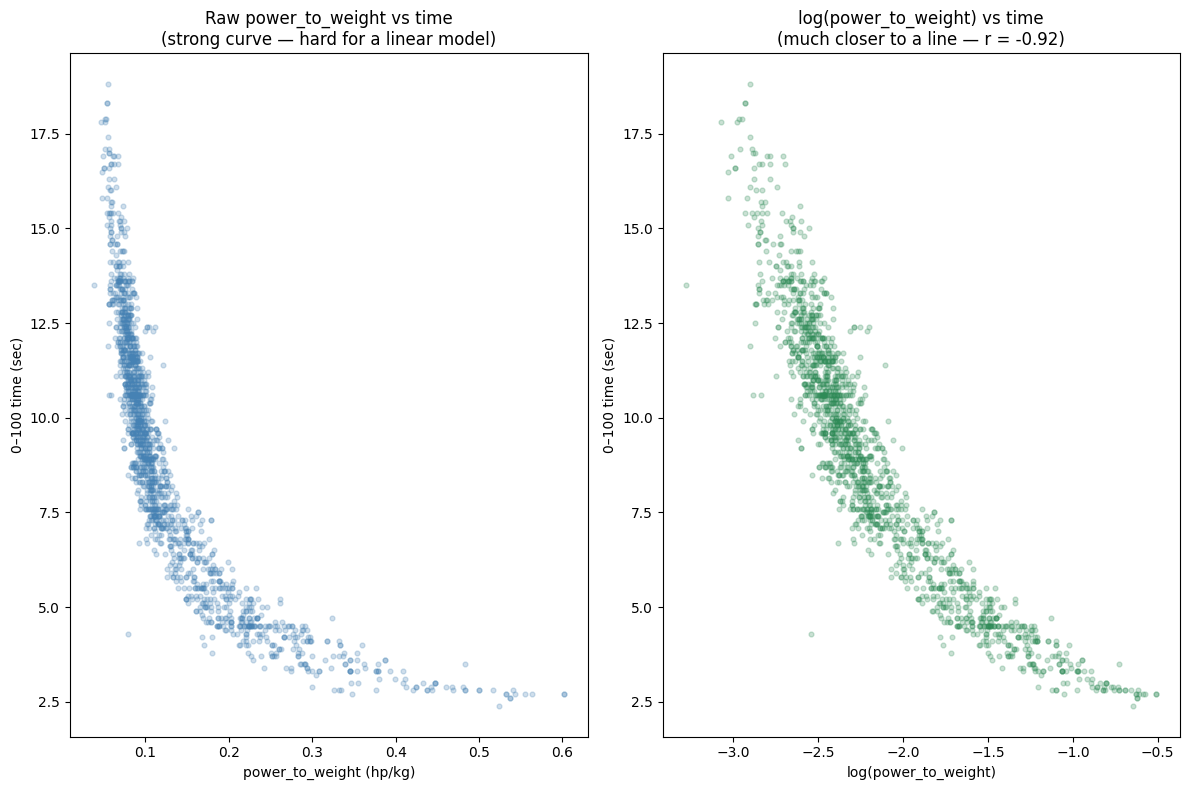

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].scatter(df['power_to_weight'], df[TARGET], alpha=0.25, s=12, color='steelblue')
axes[0].set_xlabel('power_to_weight (hp/kg)')
axes[0].set_ylabel('0–100 time (sec)')
axes[0].set_title('Raw power_to_weight vs time\n(strong curve — hard for a linear model)')

_r = np.log(df['power_to_weight']).corr(df[TARGET])
axes[1].scatter(np.log(df['power_to_weight']), df[TARGET], alpha=0.25, s=12, color='seagreen')
axes[1].set_xlabel('log(power_to_weight)')
axes[1].set_ylabel('0–100 time (sec)')
axes[1].set_title(f'log(power_to_weight) vs time\n(much closer to a line — r = {_r:.2f})')

plt.tight_layout()
plt.savefig('../docs/power_to_weight_log.png', dpi=120)
plt.show()

---
## Step 2 - `log(power_to_weight)`: the key feature

Taking the logarithm turns the power-law curve into a straight line - exactly what a
linear model can fit. This feature does most of the work.

In [5]:
df['log_power_to_weight'] = np.log(df['power_to_weight'])

results.append(evaluate(df, RAW_FEATURES + ['power_to_weight', 'log_power_to_weight'],
                        'Step 2: + log(power_to_weight)'))

Step 2: + log(power_to_weight)             CV MAE = 0.680 sec   R² = 0.910


---
## Step 3 - `torque_to_weight`

Power determines top-end speed, but torque determines how hard the car launches off the
line - which matters a lot for the 0–100 sprint. We add torque-to-weight, and its log,
for the same power-law reason.

In [6]:
df['torque_to_weight']     = df['stock_torque_nm'] / df['weight_kg']
df['log_torque_to_weight'] = np.log(df['torque_to_weight'])

results.append(evaluate(df,
    RAW_FEATURES + ['power_to_weight', 'log_power_to_weight',
                    'torque_to_weight', 'log_torque_to_weight'],
    'Step 3: + torque_to_weight'))

Step 3: + torque_to_weight                 CV MAE = 0.671 sec   R² = 0.913


---
## Step 4 - Binary flags for drivetrain and powertrain

Two cars with identical power-to-weight can launch very differently:
- All-wheel drive puts power down without wheelspin → quicker off the line.
- Electric vehicles deliver peak torque instantly from 0 rpm → very quick initial
  acceleration despite their weight.
- Turbocharged engines behave differently from naturally aspirated ones.

Integer category codes (0, 1, 2) imply a false ordering. Explicit 0/1 flags are cleaner
for the model to use.

In [7]:
df['is_awd']          = (df['drivetrain'] == '4 wheel drive').astype(int)
df['is_ev']           = (df['engine_type'] == 'EV').astype(int)
df['is_turbocharged'] = (df['engine_type'] == 'Turbocharged').astype(int)
df['is_manual']       = (df['transmission'] == 'Manual').astype(int)

FLAGS = ['is_awd', 'is_ev', 'is_turbocharged', 'is_manual']

results.append(evaluate(df,
    RAW_FEATURES + ['power_to_weight', 'log_power_to_weight',
                    'torque_to_weight', 'log_torque_to_weight'] + FLAGS,
    'Step 4: + drivetrain/powertrain flags'))

Step 4: + drivetrain/powertrain flags      CV MAE = 0.682 sec   R² = 0.910


---
## Step 5 - `power_per_litre` (engine tune intensity)

How hard an engine is tuned - its specific output - is a proxy for how aggressively it's
built. A 2.0-litre making 300 hp is highly strung; a 2.0-litre making 140 hp is relaxed.

$$power\_per\_litre = \frac{stock\_hp}{displacement\_cc / 1000}$$

EVs have no displacement, so we guard against divide-by-zero.

In [8]:
# displacement in litres; avoid div-by-zero for EVs (displacement imputed, never 0, but guard anyway)
litres = (df['displacement_cc'] / 1000).replace(0, np.nan)
df['power_per_litre'] = (df['stock_hp'] / litres).fillna(0)

ALL_FEATURES = (RAW_FEATURES +
                ['power_to_weight', 'log_power_to_weight',
                 'torque_to_weight', 'log_torque_to_weight',
                 'power_per_litre'] + FLAGS)

results.append(evaluate(df, ALL_FEATURES, 'Step 5: + power_per_litre (final)'))

Step 5: + power_per_litre (final)          CV MAE = 0.679 sec   R² = 0.911


---
## The progression - does each feature earn its place?

                                label   cv_mae    cv_r2
            Step 0: raw features only 1.408395 0.662404
            Step 1: + power_to_weight 1.356330 0.640417
       Step 2: + log(power_to_weight) 0.679835 0.910495
           Step 3: + torque_to_weight 0.671031 0.912578
Step 4: + drivetrain/powertrain flags 0.681591 0.910093
    Step 5: + power_per_litre (final) 0.678731 0.910693


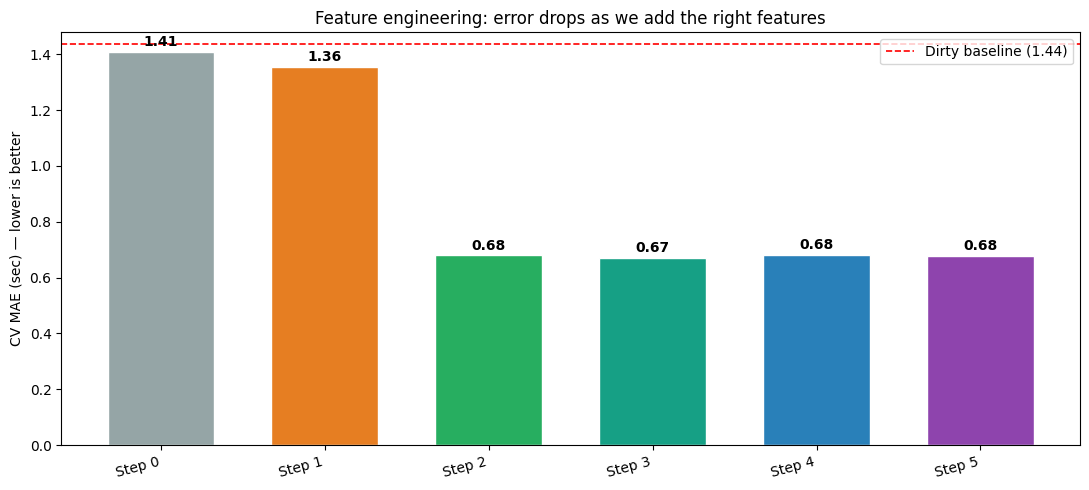

In [9]:
res_df = pd.DataFrame(results)
print(res_df[['label', 'cv_mae', 'cv_r2']].to_string(index=False))

import json
with open('../data/interim/baseline_scores.json') as _f:
    DIRTY_MAE = json.load(_f)['dirty_cv_mae']  # from notebook 02 — never goes stale

fig, ax = plt.subplots(figsize=(11, 5))
labels = [r['label'].split(':')[0] for r in results]
maes   = [r['cv_mae'] for r in results]
colors = ['#95a5a6', '#e67e22', '#27ae60', '#16a085', '#2980b9', '#8e44ad']
bars = ax.bar(labels, maes, color=colors[:len(labels)], edgecolor='white', width=0.65)
ax.axhline(DIRTY_MAE, color='red', linestyle='--', lw=1.2, label=f'Dirty baseline ({DIRTY_MAE:.2f})')
ax.set_ylabel('CV MAE (sec) — lower is better')
ax.set_title('Feature engineering: error drops as we add the right features')
ax.legend()
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, mae + 0.02, f'{mae:.2f}',
            ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../docs/feature_progression.png', dpi=120)
plt.show()

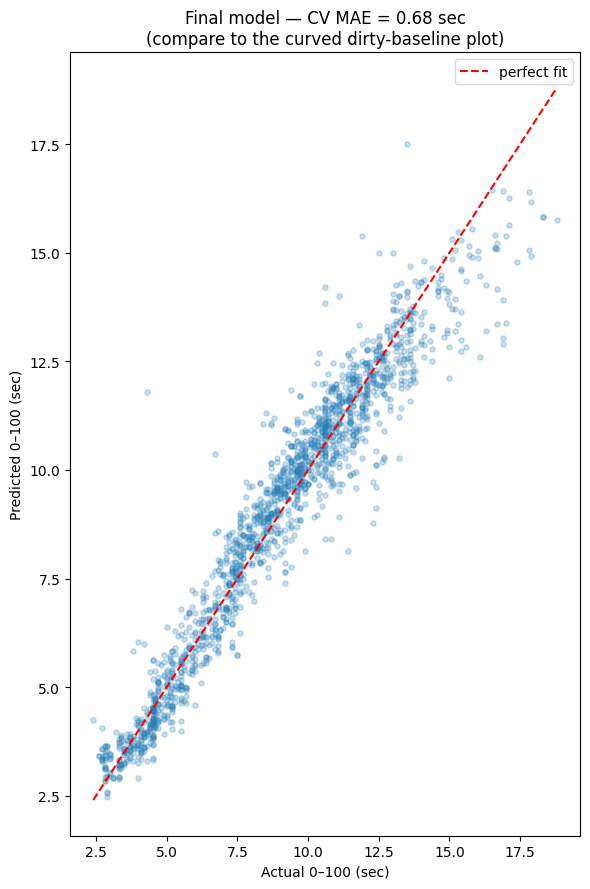

In [10]:
# Final predicted-vs-actual scatter, to compare against the dirty baseline plot
d = df.dropna(subset=ALL_FEATURES + [TARGET])
X, y = d[ALL_FEATURES].values, d[TARGET].values
final_model = LinearRegression().fit(X, y)
y_pred = final_model.predict(X)

fig, ax = plt.subplots(figsize=(6, 9))
ax.scatter(y, y_pred, alpha=0.25, s=14, color='#2980b9')
lims = [y.min(), y.max()]
ax.plot(lims, lims, 'r--', lw=1.5, label='perfect fit')
ax.set_xlabel('Actual 0–100 (sec)')
ax.set_ylabel('Predicted 0–100 (sec)')
final_mae = results[-1]['cv_mae']
ax.set_title(f'Final model — CV MAE = {final_mae:.2f} sec\n(compare to the curved dirty-baseline plot)')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/final_model_scatter.png', dpi=120)
plt.show()

---
## Which features matter most?

We standardise the features (so coefficients are comparable) and look at the magnitude of
each coefficient. A bigger absolute coefficient = bigger influence on the prediction.

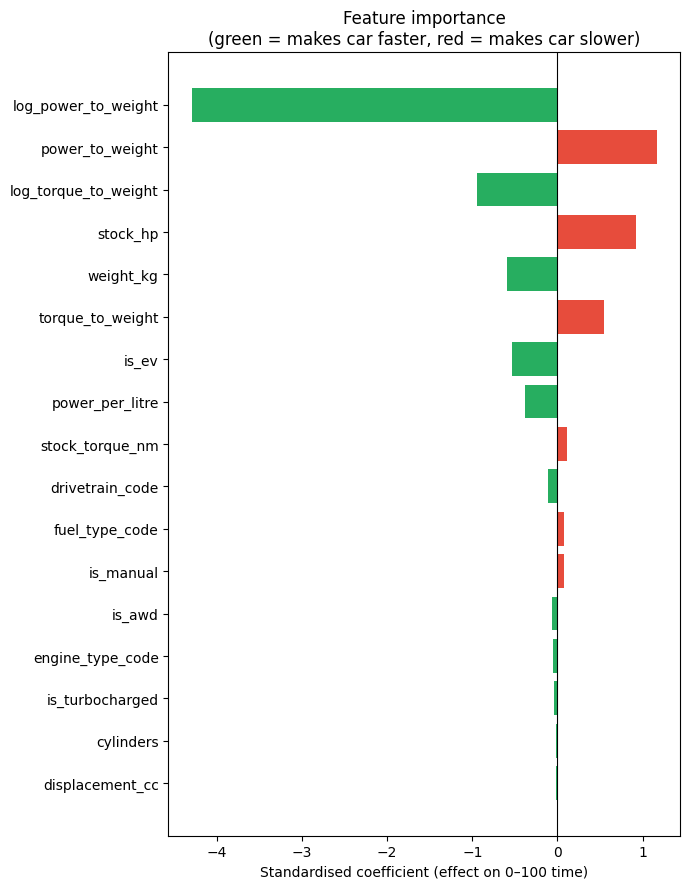

             feature  coefficient
 log_power_to_weight    -4.295518
     power_to_weight     1.166430
log_torque_to_weight    -0.941306
            stock_hp     0.924390
           weight_kg    -0.588932
    torque_to_weight     0.545852
               is_ev    -0.529541
     power_per_litre    -0.380002
     stock_torque_nm     0.117689
     drivetrain_code    -0.111794
      fuel_type_code     0.080174
           is_manual     0.076214
              is_awd    -0.065927
    engine_type_code    -0.048099
     is_turbocharged    -0.040887
           cylinders    -0.019695
     displacement_cc    -0.016028


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(d[ALL_FEATURES].values)
model_std = LinearRegression().fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'coefficient': model_std.coef_,
}).reindex().sort_values('coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(7, 9))
colors = ['#e74c3c' if c > 0 else '#27ae60' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_xlabel('Standardised coefficient (effect on 0–100 time)')
ax.set_title('Feature importance\n(green = makes car faster, red = makes car slower)')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=120)
plt.show()

print(coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).to_string(index=False))

---
## Save the final feature-engineered dataset

In [12]:
ENGINEERED = ['power_to_weight', 'log_power_to_weight',
              'torque_to_weight', 'log_torque_to_weight',
              'power_per_litre'] + FLAGS

KEEP = ['car_id', 'make', 'model', 'variant', 'year_from',
        'stock_hp', 'weight_kg', 'displacement_cc', 'cylinders', 'stock_torque_nm',
        'drivetrain', 'engine_type', 'fuel_type', 'transmission',
        'top_speed_stock', 'co2_gkm'] + ENGINEERED + [TARGET]

final = df[KEEP].copy()
final.to_csv('../data/final/cars_features.csv', index=False)
print(f"Saved → data/final/cars_features.csv  ({final.shape[0]} rows × {final.shape[1]} cols)")
print(f"Engineered features added: {ENGINEERED}")

Saved → data/final/cars_features.csv  (1696 rows × 26 cols)
Engineered features added: ['power_to_weight', 'log_power_to_weight', 'torque_to_weight', 'log_torque_to_weight', 'power_per_litre', 'is_awd', 'is_ev', 'is_turbocharged', 'is_manual']


---
## Summary - the full process

| Stage | CV MAE (sec) | What changed |
|-------|--------------|--------------|
| Dirty baseline (nb 02) | see chart | raw data, raw features |
| After cleaning (nb 03) | ~same | nulls fixed, no new features |
| + log(power_to_weight) | *(see Step 2)* | linearised the power law |
| + all engineered features | *(see Step 5)* | drivetrain, EV, torque, tune |

What this shows: cleaning made the data *correct*, but feature
engineering made it *useful*. The biggest single jump came from one feature - 
`log(power_to_weight)` - because it matched the representation to the underlying physics.
Same data, same model, dramatically better predictions.